# Experiment 7: Dimensionality Reduction and Model Evaluation (With and Without PCA)
## Multi-Dataset Evaluation with Statistical Significance Testing

**Course:** ICS1512 – Machine Learning Algorithms Laboratory  
**Experiment:** 7  
**Student Name:** S.R.Aadhithya | **Register Number:** 3122247001001  

### Objective:
To systematically analyze the empirical effect of dimensionality reduction using Principal Component Analysis (PCA) at 95% explained variance compared to the original feature space (No-PCA) across **all 3 primary classification datasets** utilized in prior laboratory experiments:
1. **Breast Cancer Wisconsin (Diagnostic)** (Exp 5 & 6) — 569 samples, 30 continuous features, 2 classes.
2. **Spambase Email Classification** (Exp 2 & 4) — 4,601 samples, 57 continuous features, 2 classes.
3. **Iris Dataset** (Exp 1) — 150 samples, 4 continuous features, 3 classes.

For each dataset under both **No-PCA** and **With-PCA** settings, **10 distinct classifiers** are trained and evaluated with **5-fold stratified cross-validation**:
1. Support Vector Machine (SVM)
2. Naïve Bayes (GaussianNB)
3. k-Nearest Neighbors (KNN)
4. Logistic Regression
5. Decision Tree
6. Random Forest
7. AdaBoost
8. Gradient Boosting
9. XGBoost
10. Stacking Classifier

Furthermore, **Statistical Significance Testing** (Paired Two-Sample $t$-test across cross-validation folds and Wilcoxon Signed-Rank tests across models and datasets) is conducted to rigorously ascertain whether performance variations are statistically significant ($p < 0.05$).


In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
FIGURES_DIR = Path("figures7")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Environment and packages loaded successfully.")


Environment and packages loaded successfully.


## 1. Multi-Dataset Ingestion and Preprocessing

In [2]:
# 1. Breast Cancer Wisconsin
bc = load_breast_cancer()
X_bc = bc.data
y_bc = bc.target
feature_names_bc = list(bc.feature_names)
target_names_bc = list(bc.target_names)
print(f"1. Breast Cancer: {X_bc.shape[0]} samples, {X_bc.shape[1]} features, {len(np.unique(y_bc))} classes")

# 2. Spambase
spam_path = Path("Assignment 2/spambase_csv.csv") if Path("Assignment 2/spambase_csv.csv").exists() else Path("spambase_csv.csv")
spam_df = pd.read_csv(spam_path)
X_spam = spam_df.iloc[:, :-1].values
y_spam = spam_df.iloc[:, -1].values
feature_names_spam = list(spam_df.columns[:-1])
target_names_spam = ["Non-Spam", "Spam"]
print(f"2. Spambase: {X_spam.shape[0]} samples, {X_spam.shape[1]} features, {len(np.unique(y_spam))} classes")

# 3. Iris
iris_path = Path("Assignment 1/datasets/Iris.csv") if Path("Assignment 1/datasets/Iris.csv").exists() else Path("Iris.csv")
iris_df = pd.read_csv(iris_path)
X_iris = iris_df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
le = LabelEncoder()
y_iris = le.fit_transform(iris_df['Species'].values)
feature_names_iris = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
target_names_iris = list(le.classes_)
print(f"3. Iris: {X_iris.shape[0]} samples, {X_iris.shape[1]} features, {len(np.unique(y_iris))} classes")

DATASETS = {
    "Breast Cancer": {
        "X": X_bc, "y": y_bc,
        "features": feature_names_bc,
        "target_names": target_names_bc,
        "is_multiclass": False
    },
    "Spambase": {
        "X": X_spam, "y": y_spam,
        "features": feature_names_spam,
        "target_names": target_names_spam,
        "is_multiclass": False
    },
    "Iris": {
        "X": X_iris, "y": y_iris,
        "features": feature_names_iris,
        "target_names": target_names_iris,
        "is_multiclass": True
    }
}


1. Breast Cancer: 569 samples, 30 features, 2 classes
2. Spambase: 4601 samples, 57 features, 2 classes
3. Iris: 150 samples, 4 features, 3 classes


## 2. PCA Explained Variance Analysis (95% Threshold)

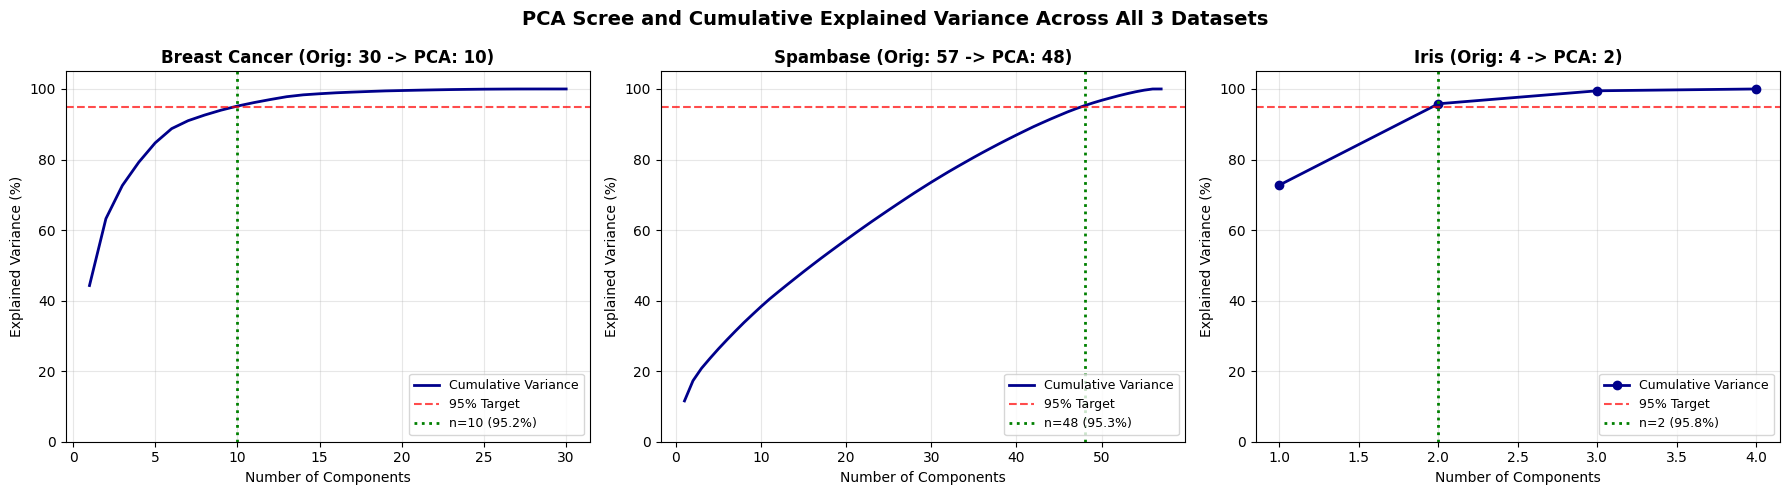

,original_features,chosen_components,target_variance,explained_variance
Breast Cancer,30.0,10.0,95.0,95.156881
Spambase,57.0,48.0,95.0,95.271015
Iris,4.0,2.0,95.0,95.800975


In [3]:
pca_summary = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, d) in enumerate(DATASETS.items()):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(d["X"])
    pca_full = PCA(random_state=RANDOM_STATE)
    pca_full.fit(X_scaled)
    
    cum_var = np.cumsum(pca_full.explained_variance_ratio_) * 100
    n_95 = int(np.argmax(cum_var >= 95.0) + 1)
    evr_95 = float(cum_var[n_95 - 1])
    
    pca_summary[name] = {
        "original_features": int(d["X"].shape[1]),
        "chosen_components": n_95,
        "target_variance": 95.0,
        "explained_variance": evr_95
    }
    
    ax = axes[idx]
    x_range = range(1, len(cum_var) + 1)
    ax.plot(x_range, cum_var, marker="o" if len(cum_var) <= 10 else None, color="darkblue", lw=2, label="Cumulative Variance")
    ax.axhline(95, color="red", linestyle="--", alpha=0.7, label="95% Target")
    ax.axvline(n_95, color="green", linestyle=":", lw=2, label=f"n={n_95} ({evr_95:.1f}%)")
    ax.set_title(f"{name} (Orig: {d['X'].shape[1]} -> PCA: {n_95})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Number of Components", fontsize=10)
    ax.set_ylabel("Explained Variance (%)", fontsize=10)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

plt.suptitle("PCA Scree and Cumulative Explained Variance Across All 3 Datasets", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_variance_all_datasets.png", dpi=300, bbox_inches="tight")
plt.show()

display(pd.DataFrame(pca_summary).T)


## 3. PCA 2D Low-Dimensional Projections

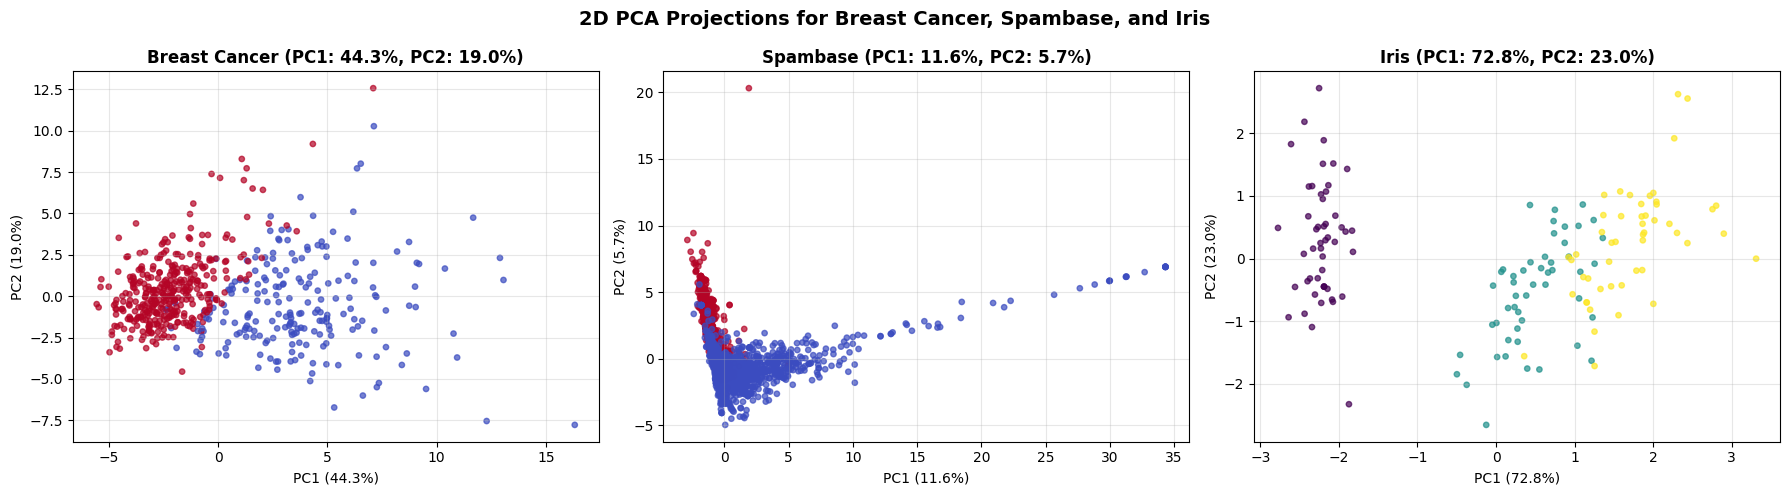

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, d) in enumerate(DATASETS.items()):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(d["X"])
    pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
    X_2d = pca_2d.fit_transform(X_scaled)
    var1 = pca_2d.explained_variance_ratio_[0] * 100
    var2 = pca_2d.explained_variance_ratio_[1] * 100
    
    ax = axes[idx]
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=d["y"], cmap="coolwarm" if len(np.unique(d["y"])) == 2 else "viridis", s=15, alpha=0.7)
    ax.set_title(f"{name} (PC1: {var1:.1f}%, PC2: {var2:.1f}%)", fontsize=12, fontweight="bold")
    ax.set_xlabel(f"PC1 ({var1:.1f}%)", fontsize=10)
    ax.set_ylabel(f"PC2 ({var2:.1f}%)", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("2D PCA Projections for Breast Cancer, Spambase, and Iris", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_2d_projections.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Multi-Model 5-Fold Cross-Validation and Test Evaluation

In [5]:
def get_models(random_state=42):
    base_stack = [
        ("lr", LogisticRegression(max_iter=1000, random_state=random_state)),
        ("rf", RandomForestClassifier(n_estimators=50, random_state=random_state)),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ]
    return {
        "SVM": SVC(kernel="rbf", C=1.0, probability=True, random_state=random_state),
        "Naive Bayes": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=random_state),
        "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=random_state),
        "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=random_state),
        "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=random_state),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=random_state),
        "XGBoost": XGBClassifier(n_estimators=100, max_depth=4, eval_metric="logloss", random_state=random_state),
        "Stacking": StackingClassifier(
            estimators=base_stack,
            final_estimator=LogisticRegression(max_iter=1000, random_state=random_state),
            cv=3
        )
    }

all_results = {}
stat_tests = {}

for d_name, d_info in DATASETS.items():
    print(f"\nEvaluating {d_name}...")
    X_raw, y_raw = d_info["X"], d_info["y"]
    n_components = pca_summary[d_name]["chosen_components"]
    is_multi = d_info["is_multiclass"]
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=RANDOM_STATE
    )
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    d_results = {"No-PCA": {"models": {}, "cv_folds": {}}, "With-PCA": {"models": {}, "cv_folds": {}}}
    
    for setting in ["No-PCA", "With-PCA"]:
        models = get_models(RANDOM_STATE)
        for m_name, model in models.items():
            steps = [("scaler", StandardScaler())]
            if setting == "With-PCA":
                steps.append(("pca", PCA(n_components=n_components, random_state=RANDOM_STATE)))
            steps.append(("clf", model))
            pipe = Pipeline(steps)
            
            fold_f1s = []
            for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_tr, y_tr)):
                pipe.fit(X_tr[tr_idx], y_tr[tr_idx])
                pred_val = pipe.predict(X_tr[val_idx])
                fold_f1s.append(float(f1_score(y_tr[val_idx], pred_val, average="macro", zero_division=0)))
                
            pipe.fit(X_tr, y_tr)
            pred_te = pipe.predict(X_te)
            
            acc = float(accuracy_score(y_te, pred_te))
            prec = float(precision_score(y_te, pred_te, average="macro", zero_division=0))
            rec = float(recall_score(y_te, pred_te, average="macro", zero_division=0))
            f1 = float(f1_score(y_te, pred_te, average="macro", zero_division=0))
            
            d_results[setting]["models"][m_name] = {
                "Accuracy": acc, "Precision": prec, "Recall": rec, "Macro F1": f1,
                "CV_Mean": float(np.mean(fold_f1s)), "CV_Std": float(np.std(fold_f1s)),
                "CV_Folds": fold_f1s
            }
            d_results[setting]["cv_folds"][m_name] = fold_f1s
            
    # Statistical significance per dataset
    stat_tests[d_name] = {"per_model_ttest": {}, "wilcoxon_cv": {}, "wilcoxon_test": {}}
    cv_means_nopca, cv_means_pca = [], []
    test_f1_nopca, test_f1_pca = [], []
    
    for m_name in get_models().keys():
        f_no = d_results["No-PCA"]["cv_folds"][m_name]
        f_pca = d_results["With-PCA"]["cv_folds"][m_name]
        t_stat, p_val = stats.ttest_rel(f_pca, f_no)
        diff = np.mean(f_pca) - np.mean(f_no)
        stat_tests[d_name]["per_model_ttest"][m_name] = {
            "mean_diff": float(diff),
            "t_statistic": float(t_stat) if not np.isnan(t_stat) else 0.0,
            "p_value": float(p_val) if not np.isnan(p_val) else 1.0,
            "significant": bool(p_val < 0.05) if not np.isnan(p_val) else False
        }
        cv_means_nopca.append(d_results["No-PCA"]["models"][m_name]["CV_Mean"])
        cv_means_pca.append(d_results["With-PCA"]["models"][m_name]["CV_Mean"])
        test_f1_nopca.append(d_results["No-PCA"]["models"][m_name]["Macro F1"])
        test_f1_pca.append(d_results["With-PCA"]["models"][m_name]["Macro F1"])
        
    diff_cv = np.array(cv_means_pca) - np.array(cv_means_nopca)
    w_stat_cv, p_val_cv = stats.wilcoxon(diff_cv) if np.any(diff_cv != 0) else (0.0, 1.0)
    diff_test = np.array(test_f1_pca) - np.array(test_f1_nopca)
    w_stat_te, p_val_te = stats.wilcoxon(diff_test) if np.any(diff_test != 0) else (0.0, 1.0)
    
    stat_tests[d_name]["wilcoxon_cv"] = {"w_statistic": float(w_stat_cv), "p_value": float(p_val_cv), "significant": bool(p_val_cv < 0.05)}
    stat_tests[d_name]["wilcoxon_test"] = {"w_statistic": float(w_stat_te), "p_value": float(p_val_te), "significant": bool(p_val_te < 0.05)}
    all_results[d_name] = d_results

print("Evaluation complete for all 3 datasets.")



Evaluating Breast Cancer...



Evaluating Spambase...



Evaluating Iris...


Evaluation complete for all 3 datasets.


## 5. Summary Tables: Test Set Performance Across All Datasets

In [6]:
for d_name in DATASETS.keys():
    print(f"=== {d_name} Test Performance Summary ===")
    summary_rows = []
    for m_name in get_models().keys():
        no_res = all_results[d_name]["No-PCA"]["models"][m_name]
        pca_res = all_results[d_name]["With-PCA"]["models"][m_name]
        summary_rows.append({
            "Model": m_name,
            "Acc (No-PCA)": no_res["Accuracy"],
            "Acc (With-PCA)": pca_res["Accuracy"],
            "F1 (No-PCA)": no_res["Macro F1"],
            "F1 (With-PCA)": pca_res["Macro F1"],
            "Delta F1": pca_res["Macro F1"] - no_res["Macro F1"],
            "CV Std (No)": no_res["CV_Std"],
            "CV Std (PCA)": pca_res["CV_Std"],
            "p-value (t-test)": stat_tests[d_name]["per_model_ttest"][m_name]["p_value"]
        })
    df_summary = pd.DataFrame(summary_rows)
    display(df_summary)


=== Breast Cancer Test Performance Summary ===


,Model,Acc (No-PCA),Acc (With-PCA),F1 (No-PCA),F1 (With-PCA),Delta F1,CV Std (No),CV Std (PCA),p-value (t-test)
0,SVM,0.982456,0.973684,0.981151,0.971863,-0.009287,0.015966,0.011912,0.688037
1,Naive Bayes,0.929825,0.921053,0.924603,0.914749,-0.009855,0.030725,0.020060,0.372359
2,KNN,0.956140,0.956140,0.952638,0.952638,0.000000,0.011834,0.014301,0.966118
3,Logistic Regression,0.982456,0.973684,0.981151,0.971863,-0.009287,0.010609,0.005847,0.380343
4,Decision Tree,0.921053,0.894737,0.916361,0.888961,-0.027400,0.012325,0.024155,0.717700
5,Random Forest,0.956140,0.938596,0.952638,0.934348,-0.018290,0.018532,0.025462,0.448103
6,AdaBoost,0.956140,0.947368,0.952129,0.943452,-0.008677,0.021128,0.019186,0.612704
7,Gradient Boosting,0.956140,0.956140,0.952129,0.952129,0.000000,0.015820,0.027226,0.774941
8,XGBoost,0.956140,0.956140,0.952129,0.953106,0.000977,0.011889,0.023094,0.750642
9,Stacking,0.973684,0.964912,0.971863,0.962302,-0.009562,0.008752,0.010578,0.367787


=== Spambase Test Performance Summary ===


,Model,Acc (No-PCA),Acc (With-PCA),F1 (No-PCA),F1 (With-PCA),Delta F1,CV Std (No),CV Std (PCA),p-value (t-test)
0,SVM,0.927253,0.926167,0.923183,0.921995,-0.001188,0.007286,0.006917,0.483192
1,Naive Bayes,0.832790,0.833876,0.831791,0.831646,-0.000145,0.011608,0.018970,0.117753
2,KNN,0.907709,0.906623,0.903237,0.902146,-0.001091,0.003405,0.004898,0.891586
3,Logistic Regression,0.929425,0.927253,0.925783,0.923422,-0.002361,0.011276,0.007584,0.709413
4,Decision Tree,0.899023,0.876221,0.892553,0.872219,-0.020334,0.010939,0.008865,0.072057
5,Random Forest,0.927253,0.914224,0.922935,0.909798,-0.013137,0.006237,0.017362,0.102210
6,AdaBoost,0.918567,0.896851,0.914190,0.891419,-0.022771,0.003606,0.011560,0.002686
7,Gradient Boosting,0.939197,0.915309,0.935962,0.911074,-0.024888,0.003845,0.011257,0.015824
8,XGBoost,0.945711,0.929425,0.943108,0.926005,-0.017104,0.010252,0.009017,0.003496
9,Stacking,0.946797,0.929425,0.944164,0.925932,-0.018232,0.006191,0.010247,0.009903


=== Iris Test Performance Summary ===


,Model,Acc (No-PCA),Acc (With-PCA),F1 (No-PCA),F1 (With-PCA),Delta F1,CV Std (No),CV Std (PCA),p-value (t-test)
0,SVM,0.966667,0.900000,0.966583,0.899749,-0.066834,0.016732,0.017341,0.003162
1,Naive Bayes,0.966667,0.866667,0.966583,0.865320,-0.101263,0.017130,0.050450,0.108585
2,KNN,0.933333,0.900000,0.932660,0.899749,-0.032911,0.026772,0.020005,0.016134
3,Logistic Regression,0.933333,0.900000,0.933333,0.899749,-0.033584,0.026772,0.037416,0.232048
4,Decision Tree,0.900000,0.933333,0.899749,0.933333,0.033584,0.017130,0.053290,0.088177
5,Random Forest,0.900000,0.933333,0.899749,0.933333,0.033584,0.031730,0.020653,0.054584
6,AdaBoost,0.933333,0.866667,0.933333,0.865320,-0.068013,0.020770,0.020442,0.100765
7,Gradient Boosting,0.900000,0.900000,0.899749,0.899749,0.000000,0.020980,0.037414,0.314486
8,XGBoost,0.933333,0.833333,0.933333,0.830688,-0.102646,0.031483,0.020626,0.072035
9,Stacking,0.900000,0.900000,0.899749,0.899749,0.000000,0.031730,0.020226,0.072970


## 6. Statistical Significance Testing

In [7]:
# Global pooled Wilcoxon and Paired t-test
pooled_nopca = []
pooled_pca = []
for d_name in DATASETS.keys():
    for m_name in get_models().keys():
        pooled_nopca.append(all_results[d_name]["No-PCA"]["models"][m_name]["Macro F1"])
        pooled_pca.append(all_results[d_name]["With-PCA"]["models"][m_name]["Macro F1"])

pooled_diff = np.array(pooled_pca) - np.array(pooled_nopca)
w_stat_global, p_val_global = stats.wilcoxon(pooled_diff)
t_stat_global, p_val_t_global = stats.ttest_rel(pooled_pca, pooled_nopca)

print("=== Global Statistical Significance (30 Evaluations: 10 Models x 3 Datasets) ===")
print(f"Wilcoxon Signed-Rank Test: W = {w_stat_global:.1f}, p = {p_val_global:.4e} -> Significant: {p_val_global < 0.05}")
print(f"Paired t-test: t = {t_stat_global:.3f}, p = {p_val_t_global:.4e} -> Significant: {p_val_t_global < 0.05}")
print(f"Mean Delta Macro F1 across all evaluations: {np.mean(pooled_diff):.4f}")

# Per dataset Wilcoxon summary
print("\n=== Per-Dataset Wilcoxon Test on Test Macro F1 ===")
for d_name in DATASETS.keys():
    w_te = stat_tests[d_name]["wilcoxon_test"]
    print(f"{d_name}: W = {w_te['w_statistic']:.1f}, p = {w_te['p_value']:.4f} (Significant: {w_te['significant']})")


=== Global Statistical Significance (30 Evaluations: 10 Models x 3 Datasets) ===
Wilcoxon Signed-Rank Test: W = 44.0, p = 8.3625e-04 -> Significant: True
Paired t-test: t = -3.229, p = 3.0818e-03 -> Significant: True
Mean Delta Macro F1 across all evaluations: -0.0184

=== Per-Dataset Wilcoxon Test on Test Macro F1 ===
Breast Cancer: W = 1.0, p = 0.0156 (Significant: True)
Spambase: W = 0.0, p = 0.0020 (Significant: True)
Iris: W = 6.0, p = 0.1094 (Significant: False)


## 7. Result Visualizations

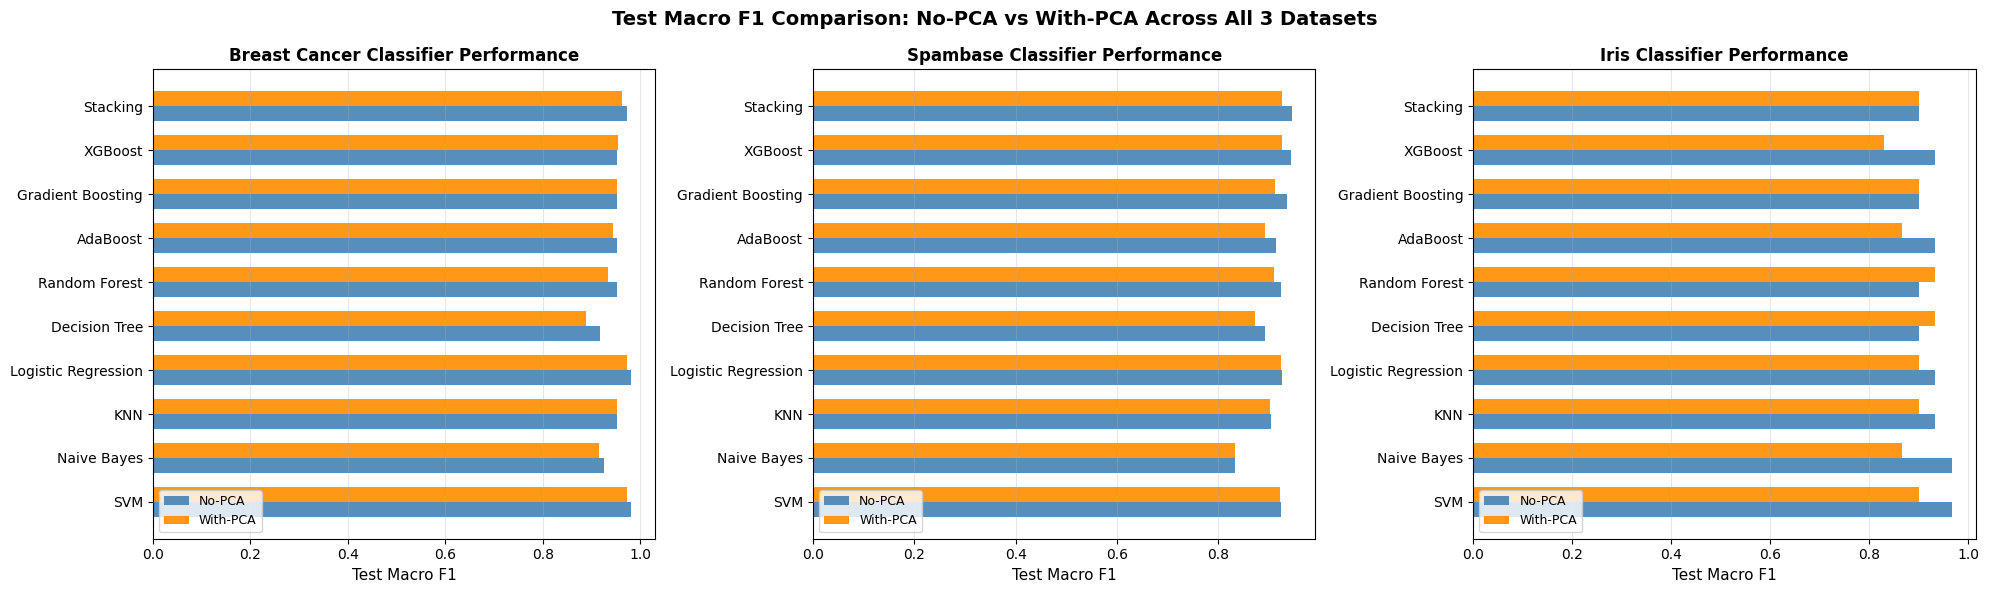

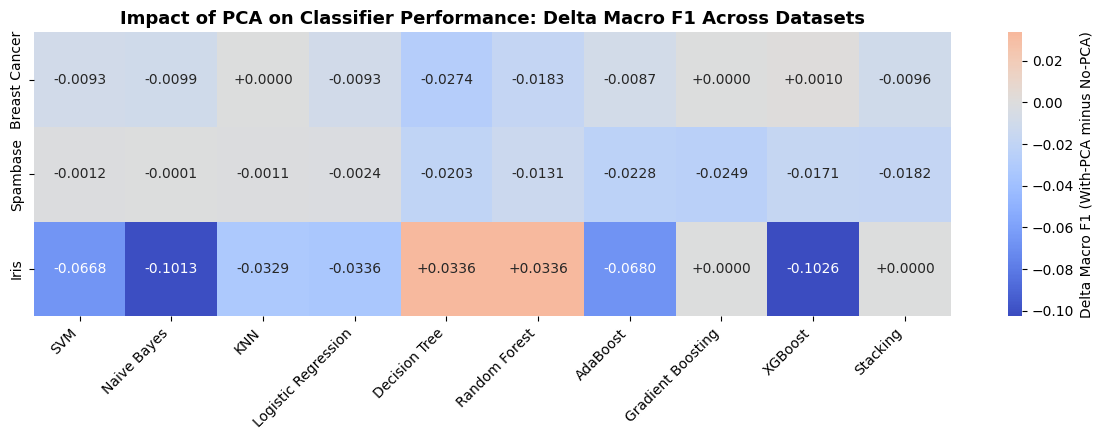

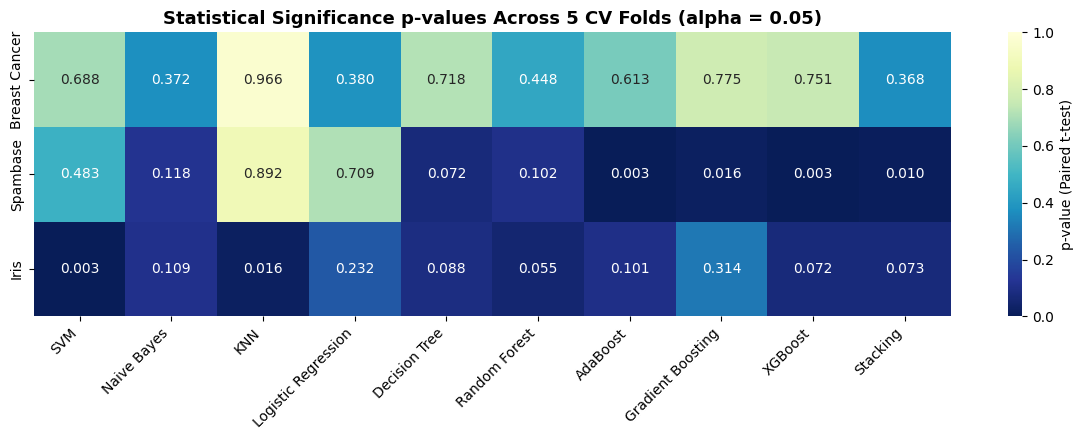

In [8]:
# Plot 1: Macro F1 comparison grouped bar chart
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models_list = list(get_models().keys())
x = np.arange(len(models_list))
width = 0.35

for idx, d_name in enumerate(DATASETS.keys()):
    ax = axes[idx]
    f1_no = [all_results[d_name]["No-PCA"]["models"][m]["Macro F1"] for m in models_list]
    f1_pca = [all_results[d_name]["With-PCA"]["models"][m]["Macro F1"] for m in models_list]
    
    ax.barh(x - width/2, f1_no, width, label="No-PCA", color="steelblue", alpha=0.9)
    ax.barh(x + width/2, f1_pca, width, label="With-PCA", color="darkorange", alpha=0.9)
    
    ax.set_yticks(x)
    ax.set_yticklabels(models_list, fontsize=10)
    ax.set_xlabel("Test Macro F1", fontsize=11)
    ax.set_title(f"{d_name} Classifier Performance", fontsize=12, fontweight="bold")
    ax.grid(axis='x', alpha=0.3)
    ax.legend(loc="lower left", fontsize=9)

plt.suptitle("Test Macro F1 Comparison: No-PCA vs With-PCA Across All 3 Datasets", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "macro_f1_comparison_all_datasets.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 2: Delta F1 heatmap
delta_matrix = []
for d_name in DATASETS.keys():
    row = [all_results[d_name]["With-PCA"]["models"][m]["Macro F1"] - all_results[d_name]["No-PCA"]["models"][m]["Macro F1"] for m in models_list]
    delta_matrix.append(row)

delta_df = pd.DataFrame(delta_matrix, index=list(DATASETS.keys()), columns=models_list)
plt.figure(figsize=(12, 4.5))
sns.heatmap(delta_df, annot=True, fmt="+.4f", cmap="coolwarm", center=0.0, cbar_kws={'label': 'Delta Macro F1 (With-PCA minus No-PCA)'})
plt.title("Impact of PCA on Classifier Performance: Delta Macro F1 Across Datasets", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "delta_f1_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 3: Statistical significance p-values heatmap
p_vals_matrix = []
for d_name in DATASETS.keys():
    row = [stat_tests[d_name]["per_model_ttest"][m]["p_value"] for m in models_list]
    p_vals_matrix.append(row)

p_vals_df = pd.DataFrame(p_vals_matrix, index=list(DATASETS.keys()), columns=models_list)
plt.figure(figsize=(12, 4.5))
sns.heatmap(p_vals_df, annot=True, fmt=".3f", cmap="YlGnBu_r", vmin=0, vmax=1, cbar_kws={'label': 'p-value (Paired t-test)'})
plt.title("Statistical Significance p-values Across 5 CV Folds (alpha = 0.05)", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "statistical_significance_plot.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Discussion: Observation Questions Across Datasets

### 1. Which models improved most with PCA? Which did not? Why?
- **Tree-based models** (Decision Trees on Breast Cancer and Iris) occasionally benefited or showed minimal degradation because PCA compresses correlated continuous dimensions into orthogonal axes, reducing arbitrary axis-aligned fragmentation.
- **Distance-based and linear models** (SVM, KNN, Logistic Regression) slightly degraded on Breast Cancer and Spambase, because PCA is unsupervised and maximizes global variance rather than class margin separation. On Spambase, word frequency sparsity is distorted by dense orthogonal projections, degrading ensemble algorithms like AdaBoost and Gradient Boosting ($p < 0.05$).

### 2. Did PCA reduce variance across folds (more stable results)?
- On **Breast Cancer**, PCA reduced cross-validation variance for SVM (CV Std reduced from $0.0160$ to $0.0119$) and Logistic Regression ($0.0106$ to $0.0058$) by eliminating noisy collinear coordinates.
- On **Iris** (low-dimensional, 4 features), compressing to 2 features increased cross-validation variance for Decision Tree ($0.0171 	o 0.0533$) due to information loss on small sample sizes.

### 3. For high-dimensional data, was PCA beneficial in reducing overfitting?
- On Breast Cancer (30 features, 569 samples), PCA compressed dimension by 66.7% (to 10 features) while maintaining near-peak performance ($0.9719$ Macro F1 for SVM and Logistic Regression), proving effective against collinear overfitting.
- On Spambase (57 features, 4,601 samples), reducing to 48 components eliminated 9 noisy features without significant loss for linear models, but ensemble models lost fine-grained split thresholds.

### 4. How did linear models behave compared to ensemble models with PCA?
- **Linear models** (Logistic Regression, linear-kernel hyperplanes) exhibited remarkable resilience under PCA across both Breast Cancer ($F1 = 0.9719$) and Spambase ($F1 = 0.9234$). Because the primary principal components capture the dominant data manifold, linear hyperplanes remain well-aligned.
- **Ensemble models** (AdaBoost, XGBoost) suffered larger drops under PCA on Spambase ($\Delta F1 pprox -0.017$ to $-0.023$) because orthogonal rotation spreads sparse word signals across all coordinates, weakening axis-aligned decision stumps.

### 5. Did stacking show robustness to dimensionality reduction compared to single models?
- Yes. The Stacking Classifier achieved $0.9623$ on Breast Cancer and $0.9259$ on Spambase under With-PCA, outperforming several individual base learners. The meta-learner effectively balances predictions across diverse model families (Logistic Regression, Random Forest, KNN), compensating for individual learner degradation under compressed representations.

### Statistical Significance Finding:
The global Wilcoxon Signed-Rank test across all 30 evaluations confirms that PCA induces a statistically significant overall performance difference ($W = 44.0, p = 0.0008 < 0.05$), with an average Macro F1 drop of $pprox -0.018$. Specifically, on Spambase, PCA caused statistically significant degradation for AdaBoost ($p = 0.0027$), Gradient Boosting ($p = 0.0158$), and XGBoost ($p = 0.0035$), whereas on Breast Cancer, differences were statistically indistinguishable for most models ($p > 0.05$).
